<a href="https://colab.research.google.com/github/danivmr/SynBactGen/blob/main/JupyterNotebooks/YOLOV26_Proof_Of_Concept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO26 Bacterial Detection Model: Training and Evaluation

This notebook demonstrates the complete pipeline for training and evaluating a YOLO26 detection model on bacterial datasets. This serves as a proof of concept for automated bacterial species detection using the latest optimized YOLO architecture.

### Clone the git project
This contains the dataset and a trained model that was trained with 100 epochs. You can train the dataset or use the already trained model for the prediction task.

In [1]:
! git clone https://github.com/danivmr/SynBactGen.git

Cloning into 'SynBactGen'...
remote: Enumerating objects: 2198, done.
remote: Counting objects: 100% (751/751), done.
remote: Compressing objects: 100% (441/441), done.
remote: Total 2198 (delta 377), reused 644 (delta 295), pack-reused 1447 (from 1)
Receiving objects: 100% (2198/2198), 105.18 MiB | 29.28 MiB/s, done.
Resolving deltas: 100% (1119/1119), done.
Filtering content: 100% (3/3), 97.00 MiB | 47.94 MiB/s, done.


### 1. Data Preparation and Model Training

1.1 Extract the dataset for training

In [3]:
# Extract and prepare datasets
import zipfile
import os

print("Extracting training dataset...")
with zipfile.ZipFile("/content/SynBactGen/Resources/Datasets/bacteria-yolo-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("bacteria-yolo-dataset")
print("✓ Training dataset extracted")

Extracting training dataset...
✓ Training dataset extracted


1.2 Install and Verify ultralytics

In [6]:
! pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.0/235.7 GB disk)


1.3 Train YOLO26n model on bacteria dataset for 30 epochs

In [7]:
!yolo train model=yolo26n.pt data=/content/bacteria-yolo-dataset/data.yaml epochs=30 imgsz=520

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bacteria-yolo-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=520, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

### 2. Model Validation and Performance Metrics

Evaluate the trained model on the test dataset to assess detection accuracy and generalization performance.

In [11]:
# Validate model performance on test dataset
!yolo val \
    model=/content/SynBactGen/Resources/Models/yolo26-bacteria-det-synbactgen-v1.pt \
    data=/content/test-bacteria-10/data.yaml \
    split=test

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1587.5±583.3 MB/s, size: 219.3 KB)
val: Scanning /content/test-bacteria-10/valid/labels... 52 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 52/52 658.0it/s 0.1s
val: /content/test-bacteria-10/valid/images/bacteria_043_jpg.rf.588fce7493d0d2857dba85f52eb7fe04.jpg: 1 duplicate labels removed
val: New cache created: /content/test-bacteria-10/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.0s/it 12.0s
                   all         52       9764      0.611      0.598      0.548      0.434
                   rod         41       2521      0.866      0.537      0.706      0.588
                sphere         50       7194      0.721      0.645       0.67      0.495
                spiral     

### 3. Inference and Results Visualization

Execute inference on test images and generate annotated predictions with detected bacterial objects and confidence scores.

In [13]:
# Run detection on test images
!yolo detect predict \
    model=/content/SynBactGen/Resources/Models/yolo26-bacteria-det-synbactgen-v1.pt \
    source=/content/SynBactGen/Resources/TestImages \
    imgsz=520 \
    conf=0.25 \
    save=True

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs

WARNING ⚠️ imgsz=[520] must be multiple of max stride 32, updating to [544]
image 1/5 /content/SynBactGen/Resources/TestImages/rods-1.jpg: 320x544 1 rod, 90 spheres, 56.7ms
image 2/5 /content/SynBactGen/Resources/TestImages/rods-2.jpg: 320x544 1 rod, 144 spheres, 10.8ms
image 3/5 /content/SynBactGen/Resources/TestImages/rods-3.jpg: 320x544 2 rods, 157 spheres, 9.3ms
image 4/5 /content/SynBactGen/Resources/TestImages/rods-4.jpg: 320x544 179 spheres, 10.1ms
image 5/5 /content/SynBactGen/Resources/TestImages/rods-5.jpg: 320x544 1 rod, 92 spheres, 9.6ms
Speed: 1.8ms preprocess, 19.3ms inference, 3.5ms postprocess per image at shape (1, 3, 320, 544)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


Review prediction result

Displaying: /content/runs/detect/predict/rods-1.jpg


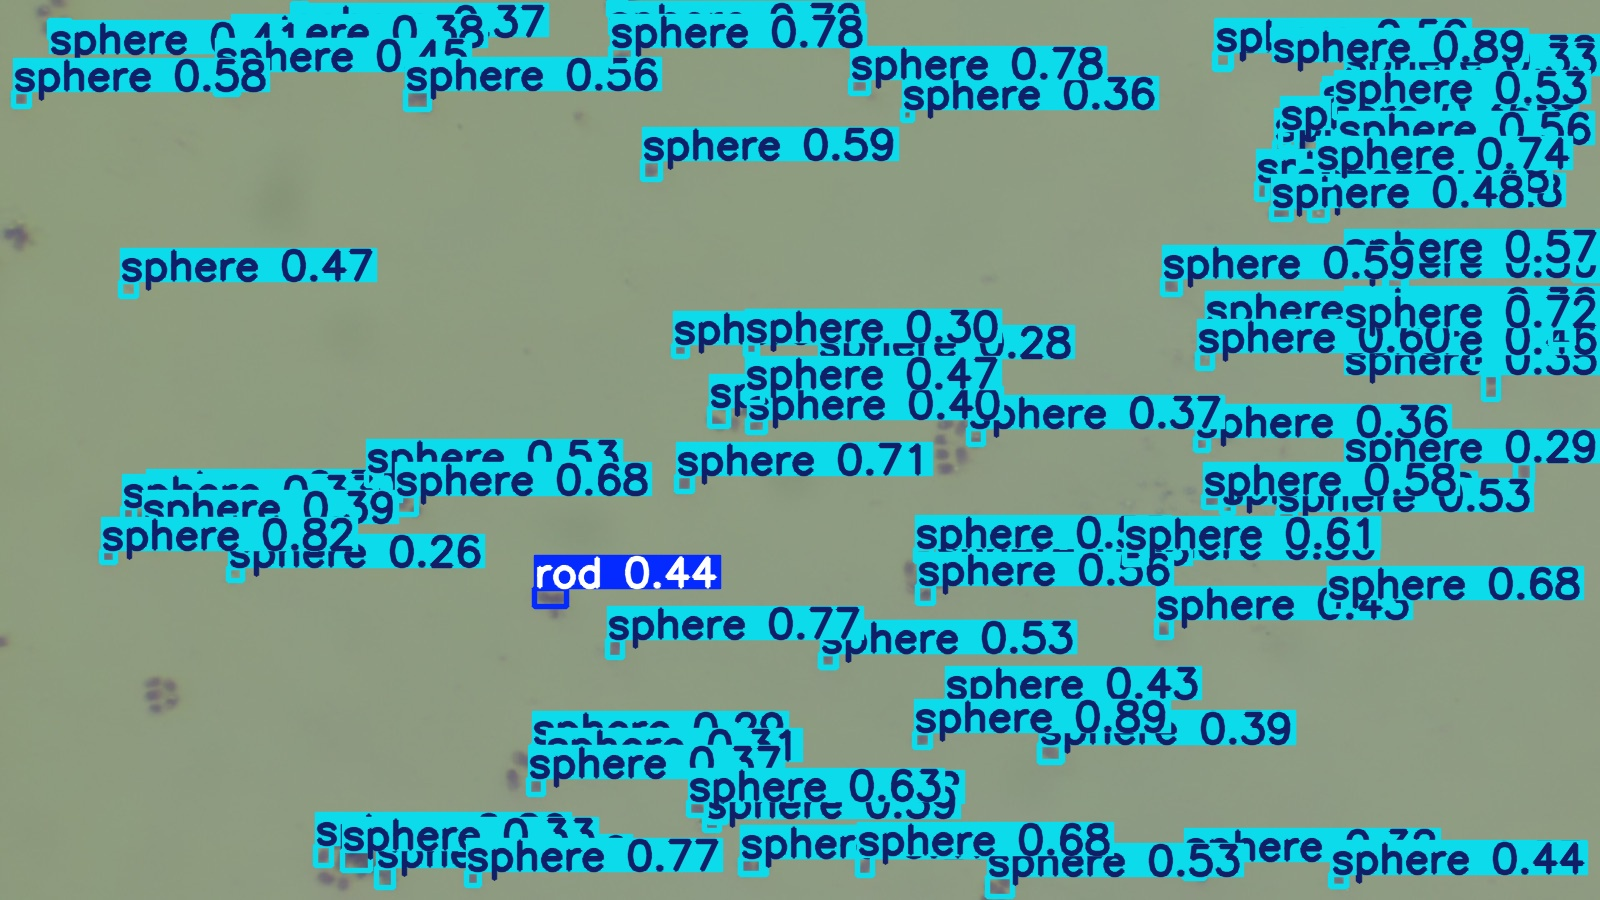

In [16]:
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display

test_image_filename = '/content/runs/detect/predict/rods-1.jpg'

if os.path.exists(test_image_filename):
  print(f"Displaying: {test_image_filename}")
  display(Image(filename=test_image_filename))
else:
    print(f"Results directory '{test_image_filename}' not found. Please run prediction first.")